In [1]:
# Basic Image Manipulation

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import Image

%matplotlib inline


In [2]:
# Download Assets

def download_and_unzip(url, save_path):
    print(f"Downloading and extracting from {url}...", end="")

    # Download the zip file using the urllib.request package
    urlretrieve(url, save_path)

    try:
        # Extract the contents of the zip file using the zipfile module
        with ZipFile(save_path, 'r') as zip_ref:
            zip_ref.extractall(os.path.dirname(save_path))

        print("Done!")
    except Exception as e:
        print(f"Error extracting zip file: {e}")

    


In [3]:
URL = r"https://www.dropbox.com/s/rys6f1vprily2bg/opencv_bootcamp_assets_NB2.zip?dl=1"

assets_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB2.zip")

# Download if assest zip file does not exist
if not os.path.exists(assets_zip_path):
    download_and_unzip(URL, assets_zip_path)


[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

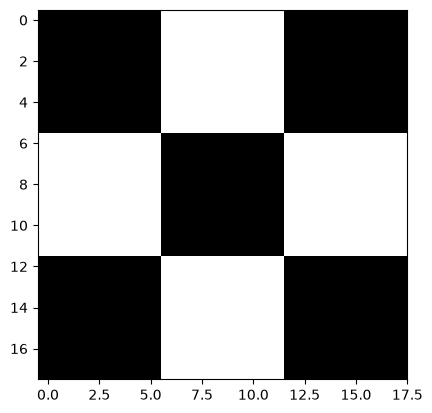

In [5]:
# Read image and display in gray scale
cb_img = cv2.imread("checkerboard_18x18.png", 0)

# Set color map to gray scale for proper rendering.
if cb_img is not None:
    plt.imshow(cb_img, cmap='gray')
    print(cb_img)
else:
    print("Image not found. Please check the file path.")



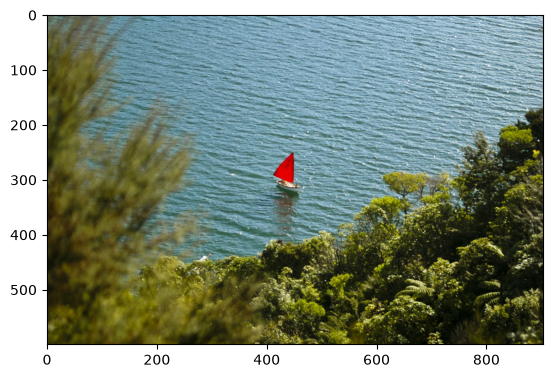

In [8]:
# Cropping Images

img_NZ_bgr = cv2.imread("New_Zealand_Boat.jpg", cv2.IMREAD_COLOR)

if img_NZ_bgr is not None:
    img_NZ_rgb = img_NZ_bgr[..., ::-1]  # Convert BGR to RGB

    plt.imshow(img_NZ_rgb)
else:
    print("Image not found. Please check the file path.")


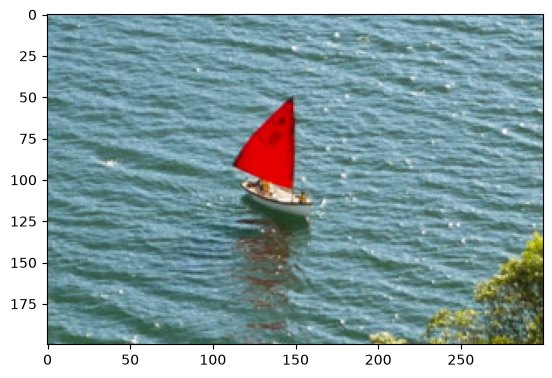

In [ ]:
# Crop out the middle region of the image

cropped_region = img_NZ_rgb[200:400, 300:600]  # Crop the region of interest
plt.imshow(cropped_region)

Original shape: (200, 300, 3), Resized shape: (400, 600, 3)


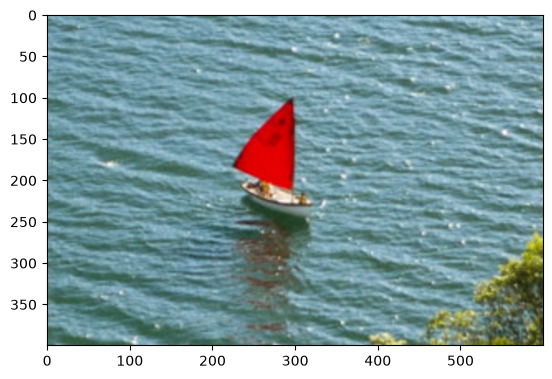

In [12]:
# Rezing Images

#Specifying scaling factor using fx and fy
resized_img = cv2.resize(cropped_region, None, fx=2, fy=2)
plt.imshow(resized_img)

print(f"Original shape: {cropped_region.shape}, Resized shape: {resized_img.shape}")


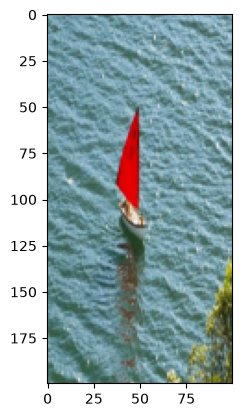

In [14]:
# Specifying the desired size of the output image
desired_width = 100
desired_height = 200
dim = (desired_width, desired_height)

# Resize background image to same size as logo image
resized_cropped_region = cv2.resize(cropped_region, dsize=dim, interpolation=cv2.INTER_AREA)
plt.imshow(resized_cropped_region)
